 Download e caricamento del dataset CIFAR-10 in corso...

2. Analisi delle dimensioni dei dati (Il 'Payload'):
-> X_train (Immagini di addestramento): (50000, 32, 32, 3)
-> y_train (Etichette di addestramento): (50000, 1)
-> X_test (Immagini di test - La nostra Validazione): (10000, 32, 32, 3)

-> Numero totale di classi: 10
3. Visualizzazione e verifica dei dati (Visual Assertion)...


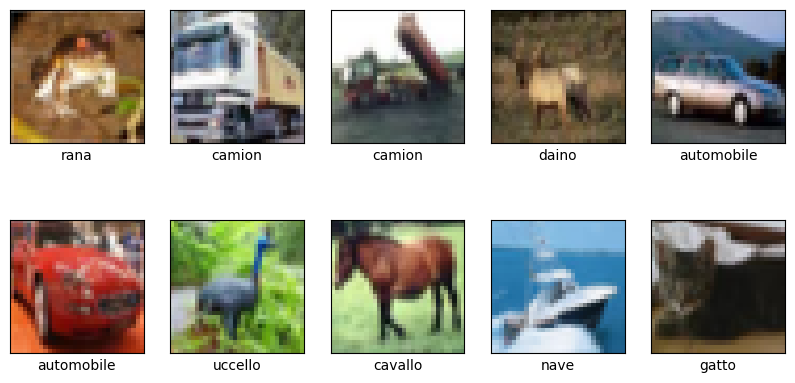


Normalizzazione dei dati in corso...
-> Valore massimo nel dataset dopo la normalizzazione: 1.0


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
import numpy as np

print(" Download e caricamento del dataset CIFAR-10 in corso...")
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

print("\n2. Analisi delle dimensioni dei dati (Il 'Payload'):")
print(f"-> X_train (Immagini di addestramento): {X_train.shape}")
print(f"-> y_train (Etichette di addestramento): {y_train.shape}")
print(f"-> X_test (Immagini di test - La nostra Validazione): {X_test.shape}")

class_names = ['aereo', 'automobile', 'uccello', 'gatto', 'daino', 
               'cane', 'rana', 'cavallo', 'nave', 'camion']

print(f"\n-> Numero totale di classi: {len(class_names)}")
print("3. Visualizzazione e verifica dei dati (Visual Assertion)...")

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    label_index = y_train[i][0]
    plt.xlabel(class_names[label_index])
plt.show()

print("\nNormalizzazione dei dati in corso...")
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"-> Valore massimo nel dataset dopo la normalizzazione: {X_train.max()}")


In [2]:
from tensorflow.keras import models, layers

print("Assemblaggio della CNN")

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

#Classificazione
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

print("\n*** ARCHITETTURA COMPLETATA ***")
model.summary()

print("Configurazione del motore di apprendimento (Optimizer & Loss)...")

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

print("Avvio della pipeline...")
print("Elaborazione di 50.000 immagini a colori in corso")
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

print("\n*** ADDESTRAMENTO COMPLETATO ***")

Assemblaggio della CNN

*** ARCHITETTURA COMPLETATA ***


c:\Coding\RilevamentoFrodiDefalut\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Configurazione del motore di apprendimento (Optimizer & Loss)...
Avvio della pipeline...
Elaborazione di 50.000 immagini a colori in corso
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4405 - loss: 1.5277 - val_accuracy: 0.5517 - val_loss: 1.2481
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5831 - loss: 1.1723 - val_accuracy: 0.5873 - val_loss: 1.1888
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6407 - loss: 1.0230 - val_accuracy: 0.6520 - val_loss: 1.0003
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6748 - loss: 0.9300 - val_accuracy: 0.6638 - val_loss: 0.9580
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7020 - loss: 0.8518 - val_accuracy: 0.6776 - val_loss: 0.9313
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7213 - loss: 0.7970 - val_accuracy: 0.7059 - val_loss: 0.8614
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7396 - lo

Generazione della dashboard di performance...


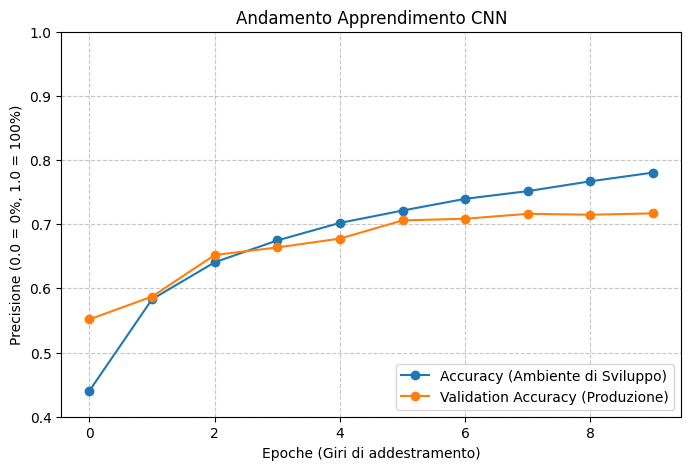

In [3]:
print("Generazione della dashboard di performance...")

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Accuracy (Ambiente di Sviluppo)', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Produzione)', marker='o')

plt.title('Andamento Apprendimento CNN')
plt.xlabel('Epoche (Giri di addestramento)')
plt.ylabel('Precisione (0.0 = 0%, 1.0 = 100%)')
plt.ylim([0.4, 1]) 
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import random
import numpy as np
import tensorflow as tf

print("Avvio Test QA Manuale (Inference)...")

random_index = random.randint(0, len(X_test) - 1)
test_image = X_test[random_index]
true_label_index = y_test[random_index][0]
true_label_name = class_names[true_label_index]

payload = np.expand_dims(test_image, axis=0)
raw_predictions = model.predict(payload, verbose=0) 
probabilities = tf.nn.softmax(raw_predictions[0])
predicted_label_index = np.argmax(probabilities)
predicted_label_name = class_names[predicted_label_index]
confidence = np.max(probabilities) * 100


plt.figure(figsize=(4, 4))
plt.imshow(test_image)
plt.xticks([])
plt.yticks([])


text_color = 'green' if predicted_label_index == true_label_index else 'red'
plt.xlabel(f"Predetto: {predicted_label_name} ({confidence:.1f}%)\nReale: {true_label_name}", 
           color=text_color, fontsize=12, fontweight='bold')
plt.title(f"Test Case #{random_index}")
plt.show()


print("\n--- Log di Debug (Top 3 Ipotesi) ---")
top_3_indices = np.argsort(probabilities)[-3:][::-1]
for i in top_3_indices:
    nome = class_names[i]
    perc = probabilities[i] * 100
    print(f"-> {nome.capitalize()}: {perc:.1f}%")